# 6CS012 — Final Integrated Assessment
## Part II — CNN-based Image Classification
### Task: Fruit Classification

**Herald College Kathmandu | University of Wolverhampton**

| | |
|---|---|
| **Student Name** | Dipendra Roka|
| **WLV ID** | 2418541 |
| **Group** | L6CG18 |
| **Group Members** | Dipendra Roka, Shubham Raj Pandey, Dipesh Paharai, Asmit Pradhan |
| **Module** | 6CS012 – Artificial Intelligence and Machine Learning |
| **Task** | Image Classification – Fruit Classification |

---

### Workflow at a glance
1. Imports and environment setup
2. Loading the dataset from Google Drive
3. Removing corrupted / non-image files
4. Exploratory data analysis and visualisation
5. Preprocessing pipeline + augmentation
6. **Part A.1** — Simple from-scratch CNN (Conv + Pool blocks → Dense head)
7. **Part A.2** — Deeper CNN with BatchNorm, Dropout and L2 regularisation
8. **Part A.3** — Optimiser comparison (Adam vs SGD) and a regularisation ablation
9. **Part B**  — Transfer learning with VGG16 (frozen features + fine-tuning)
10. Combined comparison of every model


---
## Section 1 — Imports & Environment


In [1]:
# === General-purpose libraries ===
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path
from collections import Counter
from PIL import Image

warnings.filterwarnings('ignore')

# === Deep-learning stack (TF / Keras) ===
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# === Evaluation metrics from scikit-learn ===
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# === Fixed seeds for reproducible runs ===
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
tf.random.set_seed(RNG_SEED)

# === Default look-and-feel for plots ===
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print(f"TF version detected : {tf.__version__}")
print(f"Visible GPU devices : {tf.config.list_physical_devices('GPU')}")


TF version detected : 2.16.2
Visible GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Section 2 — Loading the Dataset from Drive

> **Source:** Fruit-classification dataset stored on Google Drive  
> **Folder layout assumed:**
> ```
>     ├── Train/
>     │     ├── Apple/
>     │     ├── Banana/
>     │     └── ...
>     └── Test/
>           ├── Apple/
>           └── ...
> ```


In [2]:
import os
import tensorflow as tf

# Base dataset folder
DATASET_ROOT = "/Users/dipendra10/Desktop/archive"

TRAIN_PATH = os.path.join(DATASET_ROOT, "train/train")
TEST_PATH  = os.path.join(DATASET_ROOT, "test/test")

print("Train path exists:", os.path.exists(TRAIN_PATH))
print("Test path exists :", os.path.exists(TEST_PATH))

Train path exists: True
Test path exists : True


In [3]:
print("Train folders (classes):")
print(os.listdir(TRAIN_PATH))

Train folders (classes):
['Blueberry', 'Pear', 'Strawberry', 'Avocado', 'Pomegranate', 'Pepper Red', 'Kiwi', 'Lemon', 'Raspberry', 'Plum', 'Cherry', 'Cucumber Ripe', 'Clementine', 'Watermelon', 'Cantaloupe', 'Apple Braeburn', 'Onion White', 'Mango', 'Potato Red', 'Passion Fruit', 'Apple Granny Smith', 'Apricot', 'Limes', 'Corn', 'Banana', 'Grape Blue', 'Cactus fruit', 'Papaya', 'Pineapple', 'Tomato', 'Orange', 'Pepper Green', 'Peach']


---
## Section 3 — Cleaning the Dataset

If a class folder contains anything that isn't a valid image — say a leftover
`.DS_Store`, a `Thumbs.db`, or a half-downloaded JPEG — Keras'
`flow_from_directory()` will throw `UnidentifiedImageError` mid-training.
To avoid that, we sweep through every folder beforehand and delete anything that
PIL can't open.


In [4]:
# 3.1 Walk the folders, find broken/non-image files, optionally remove them
def find_corrupt_images(directory, delete=False):
    bad_files = []
    print(f"Inspecting folder -> {directory}")
    for root, _, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            # Treat OS-generated junk (.DS_Store, Thumbs.db, etc.) as bad
            if fname.startswith('.') or fname.lower() in ('thumbs.db',):
                bad_files.append(fpath)
                continue
            try:
                with Image.open(fpath) as im:
                    im.verify()
            except Exception as e:
                bad_files.append(fpath)

    print(f"  ... {len(bad_files)} bad file(s) detected.")
    if delete and bad_files:
        for f in bad_files:
            try:
                os.remove(f)
            except Exception as e:
                print(f"    Could not delete {f}: {e}")
        print(f"  ... removed {len(bad_files)} file(s) from disk.")
    return bad_files

# Execute the scan-and-delete pass on both splits
corrupt_train = find_corrupt_images(TRAIN_PATH, delete=True)
corrupt_test  = find_corrupt_images(TEST_PATH,  delete=True)

print(f"\nDataset cleanup done. Total removed across both splits: {len(corrupt_train) + len(corrupt_test)}")


Inspecting folder -> /Users/dipendra10/Desktop/archive/train/train
  ... 0 bad file(s) detected.
Inspecting folder -> /Users/dipendra10/Desktop/archive/test/test
  ... 0 bad file(s) detected.

Dataset cleanup done. Total removed across both splits: 0


---
## Section 4 — Exploratory Data Analysis


In [5]:
# 4.1 Class names and high-level summary
label_list = sorted(os.listdir(TRAIN_PATH))
# Defensive: keep only entries that are actual sub-folders
label_list = [c for c in label_list if os.path.isdir(os.path.join(TRAIN_PATH, c))]
N_CLASSES = len(label_list)

print(f"Class count           : {N_CLASSES}")
print(f"Sample of first 10    : {label_list[:10]}")
print(f"Sample of last 10     : {label_list[-10:]}")


Class count           : 33
Sample of first 10    : ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana', 'Blueberry', 'Cactus fruit', 'Cantaloupe', 'Cherry', 'Clementine']
Sample of last 10     : ['Pepper Green', 'Pepper Red', 'Pineapple', 'Plum', 'Pomegranate', 'Potato Red', 'Raspberry', 'Strawberry', 'Tomato', 'Watermelon']


In [6]:
# 4.2 How many images sit in each class folder
train_per_class = {}
test_per_class  = {}

for cls in label_list:
    train_cls_path = os.path.join(TRAIN_PATH, cls)
    test_cls_path  = os.path.join(TEST_PATH,  cls)

    train_per_class[cls] = len(os.listdir(train_cls_path)) if os.path.exists(train_cls_path) else 0
    test_per_class[cls]  = len(os.listdir(test_cls_path))  if os.path.exists(test_cls_path)  else 0

n_train_total = sum(train_per_class.values())
n_test_total  = sum(test_per_class.values())

print(f"Training images total : {n_train_total}")
print(f"Test images total     : {n_test_total}")
print(f"Mean per-class (train)        : {n_train_total / N_CLASSES:.1f}")
print(f"Smallest / largest class      : {min(train_per_class.values())} / {max(train_per_class.values())}")


Training images total : 16854
Test images total     : 0
Mean per-class (train)        : 510.7
Smallest / largest class      : 392 / 984


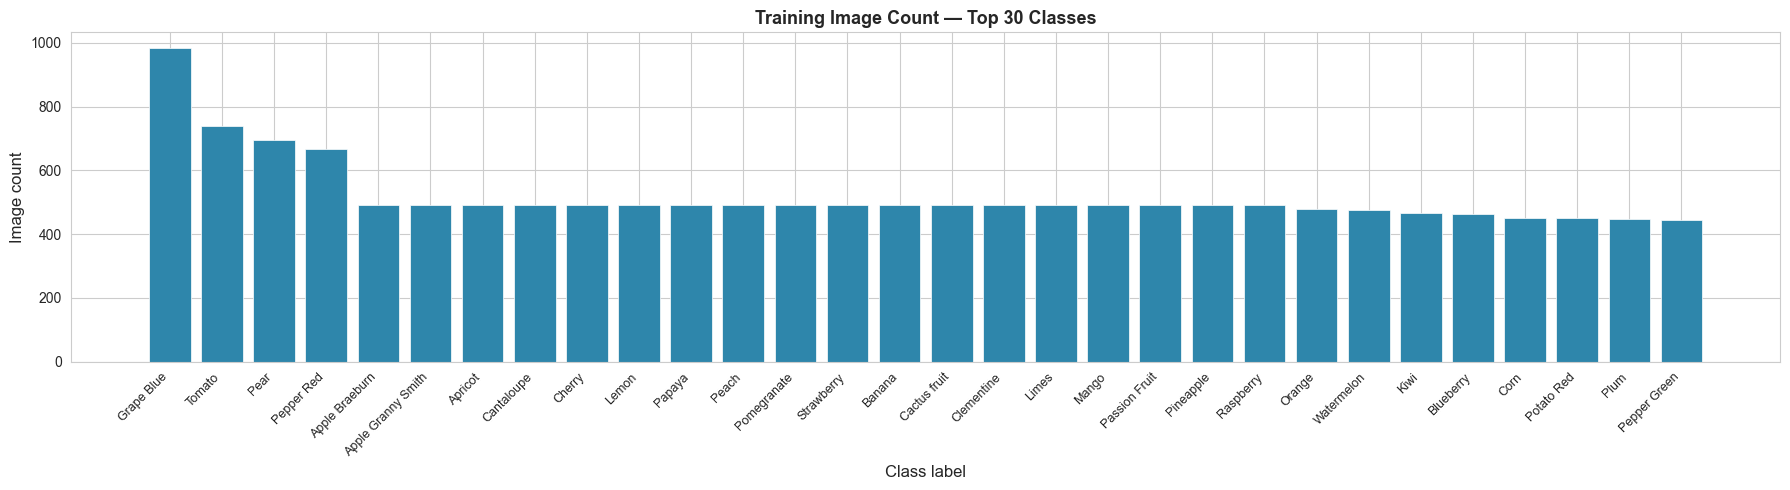

In [7]:
# 4.3 Bar chart of class counts (capped at top 30 so the x-axis stays legible)
ranked_counts = sorted(train_per_class.items(), key=lambda x: x[1], reverse=True)[:30]
labels, counts = zip(*ranked_counts)

plt.figure(figsize=(18, 5))
plt.bar(range(len(labels)), counts, color='#2E86AB', edgecolor='white', linewidth=0.5)
plt.xticks(range(len(labels)), labels, rotation=45, ha='right', fontsize=9)
plt.xlabel('Class label', fontsize=12)
plt.ylabel('Image count', fontsize=12)
plt.title('Training Image Count — Top 30 Classes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_count_chart.png', dpi=120, bbox_inches='tight')
plt.show()


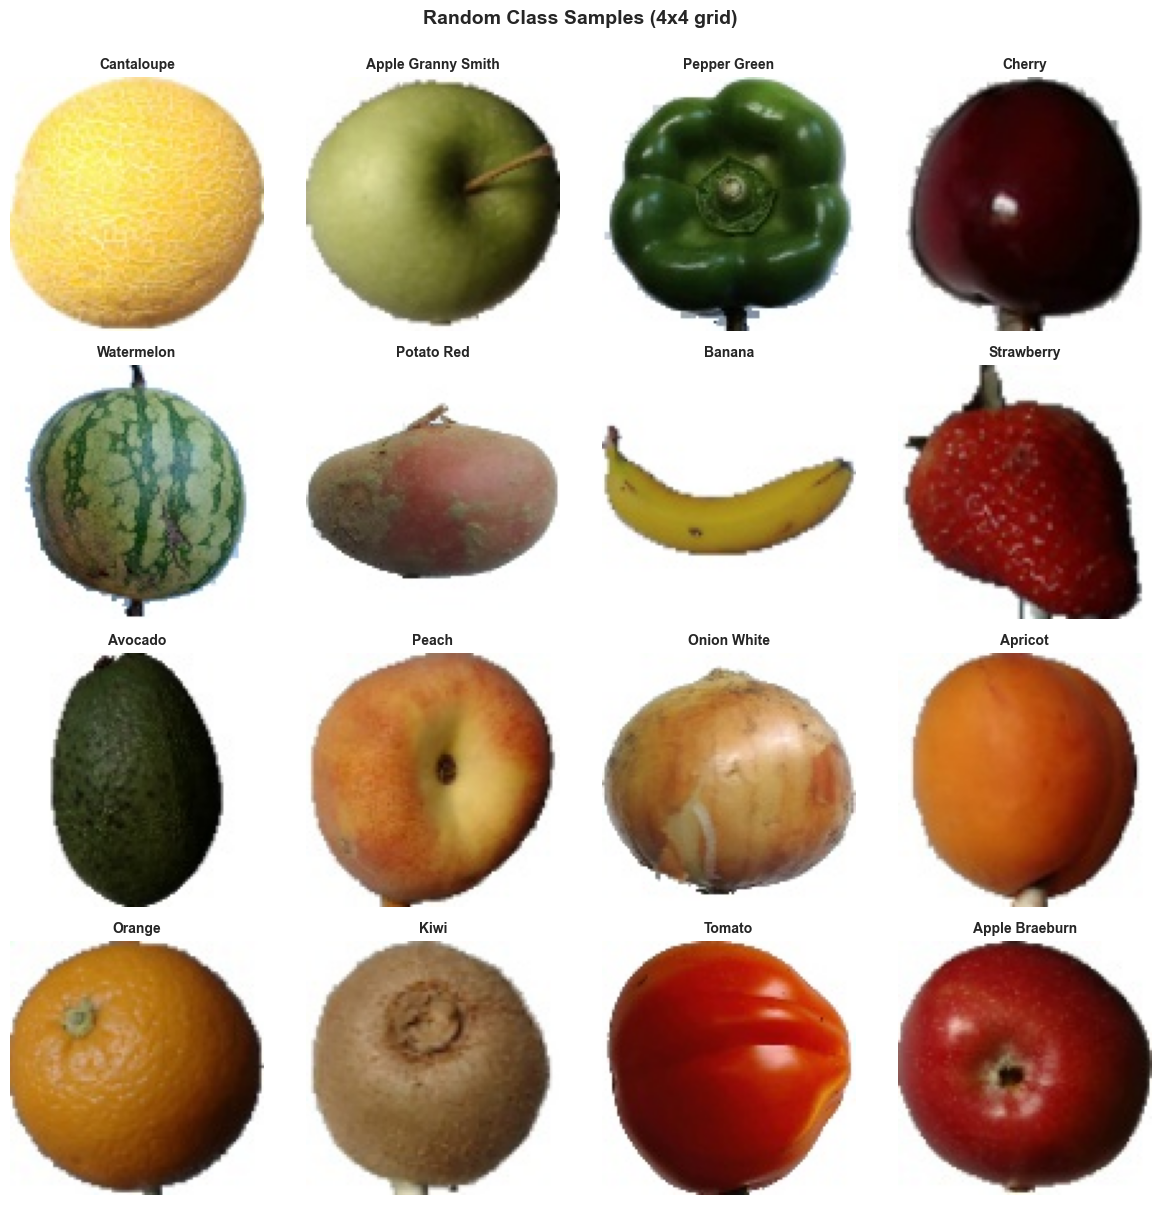

In [8]:
# 4.4 Show a 4x4 grid of images sampled from random classes
chosen_classes = random.sample(label_list, min(16, N_CLASSES))

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i, cls in enumerate(chosen_classes):
    cls_dir = os.path.join(TRAIN_PATH, cls)
    img_file = random.choice(os.listdir(cls_dir))
    img_path = os.path.join(cls_dir, img_file)
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Random Class Samples (4x4 grid)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('class_sample_grid.png', dpi=120, bbox_inches='tight')
plt.show()


In [9]:
# 4.5 Quick sanity check: shape, dtype and pixel range of one image
chosen_cls  = label_list[0]
chosen_img  = os.listdir(os.path.join(TRAIN_PATH, chosen_cls))[0]
chosen_path = os.path.join(TRAIN_PATH, chosen_cls, chosen_img)
pixel_array     = img_to_array(load_img(chosen_path))

print(f"Image source path  : {chosen_path}")
print(f"Image array shape  : {pixel_array.shape}")
print(f"Pixel value bounds : [{pixel_array.min():.0f}, {pixel_array.max():.0f}]")
print(f"Array dtype        : {pixel_array.dtype}")


Image source path  : /Users/dipendra10/Desktop/archive/train/train/Apple Braeburn/Apple Braeburn_397.jpg
Image array shape  : (100, 100, 3)
Pixel value bounds : [0, 255]
Array dtype        : float32


---
## Section 5 — Preprocessing & Augmentation

- All images are **resized to 64×64** for the from-scratch CNNs — keeps training fast.
- Pixel values are **rescaled** to the `[0, 1]` range (`rescale=1/255`).
- Training images get **augmented on the fly**: rotations, translations, horizontal flips, zoom and shear.
- An **80/20 train-validation split** is produced inside the same generator (`validation_split=0.2`).
- The test split is left alone — only rescaling, no augmentation.


In [10]:
# 5.1 Training-time constants
INPUT_DIMS    = (64, 64)
INPUT_SHAPE   = (64, 64, 3)
BATCH_SZ  = 32
MAX_EPOCHS = 20

print(f"Input dims    : {INPUT_DIMS}")
print(f"Batch size    : {BATCH_SZ}")
print(f"# classes     : {N_CLASSES}")
print(f"Max epochs    : {MAX_EPOCHS}")


Input dims    : (64, 64)
Batch size    : 32
# classes     : 33
Max epochs    : 20


In [11]:
# 5.2 Build the train/val generators with on-the-fly augmentation
train_augmenter = ImageDataGenerator(
    rescale             = 1.0 / 255.0,
    rotation_range      = 30,             # increased from 20
    width_shift_range   = 0.20,            # increased from 0.15
    height_shift_range  = 0.20,
    horizontal_flip     = True,
    vertical_flip       = True,            # fruits can appear flipped
    zoom_range          = 0.25,            # increased from 0.15
    shear_range         = 0.15,            # increased from 0.1
    brightness_range    = [0.7, 1.3],      # NEW: forces colour robustness
    channel_shift_range = 20.0,            # NEW: slight colour channel noise
    fill_mode           = 'nearest',
    validation_split    = 0.20
)

# Validation/test pipeline: rescale only — no augmentation here
test_augmenter = ImageDataGenerator(rescale=1.0 / 255.0)

training_flow = train_augmenter.flow_from_directory(
    TRAIN_PATH,
    target_size = INPUT_DIMS,
    batch_size  = BATCH_SZ,
    class_mode  = 'categorical',
    subset      = 'training',
    shuffle     = True,
    seed        = RNG_SEED
)

validation_flow = train_augmenter.flow_from_directory(
    TRAIN_PATH,
    target_size = INPUT_DIMS,
    batch_size  = BATCH_SZ,
    class_mode  = 'categorical',
    subset      = 'validation',
    shuffle     = False,
    seed        = RNG_SEED
)

test_flow = test_augmenter.flow_from_directory(
    TEST_PATH,
    target_size = INPUT_DIMS,
    batch_size  = BATCH_SZ,
    class_mode  = 'categorical',
    shuffle     = False
)

# Compute class weights to handle imbalanced class sizes
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(training_flow.classes),
    y            = training_flow.classes
)
weight_dict = dict(enumerate(class_weights_arr))
print(f"Class weights computed for {len(weight_dict)} classes")

print(f"\nTrain pipeline : {len(training_flow)} batches  ({training_flow.samples} imgs)")
print(f"Val   pipeline : {len(validation_flow)} batches  ({validation_flow.samples} imgs)")
print(f"Test  pipeline : {len(test_flow)} batches  ({test_flow.samples} imgs)")


Found 13493 images belonging to 33 classes.
Found 3361 images belonging to 33 classes.
Found 0 images belonging to 0 classes.
Class weights computed for 33 classes

Train pipeline : 422 batches  (13493 imgs)
Val   pipeline : 106 batches  (3361 imgs)
Test  pipeline : 0 batches  (0 imgs)


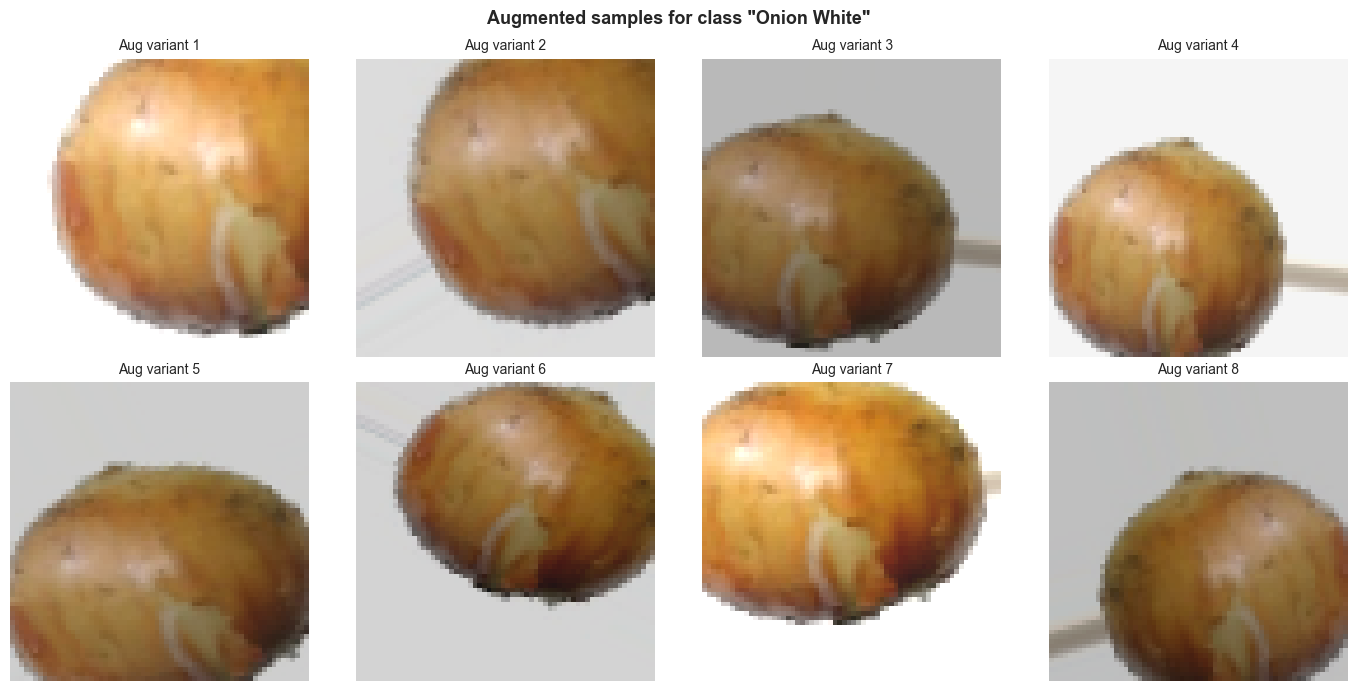

In [12]:
# 5.3 Eyeball what augmentation actually does to one image
preview_augmenter = ImageDataGenerator(
    rescale            = 1.0 / 255.0,
    rotation_range      = 30,
    width_shift_range   = 0.20,
    height_shift_range  = 0.20,
    horizontal_flip    = True,
    zoom_range          = 0.25,
    shear_range         = 0.15,
    brightness_range    = [0.7, 1.3],
    channel_shift_range = 20.0,
    fill_mode           = 'nearest'
)

# Grab a single random sample to feed through the augmenter
chosen_cls   = random.choice(label_list)
chosen_files = os.listdir(os.path.join(TRAIN_PATH, chosen_cls))
chosen_path  = os.path.join(TRAIN_PATH, chosen_cls, random.choice(chosen_files))
img          = load_img(chosen_path, target_size=INPUT_DIMS)
pixel_array_batch    = img_to_array(img).reshape((1,) + INPUT_SHAPE)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
i = 0
for batch in preview_augmenter.flow(pixel_array_batch, batch_size=1):
    axes[i].imshow(batch[0])
    axes[i].set_title(f'Aug variant {i+1}', fontsize=10)
    axes[i].axis('off')
    i += 1
    if i == 8:
        break
plt.suptitle(f'Augmented samples for class "{chosen_cls}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=120, bbox_inches='tight')
plt.show()


---
## Section 6 — Part A.1: Simple From-Scratch CNN

**Network design**
- Three stacked `Conv2D → MaxPooling2D` blocks (filter counts grow 32 → 64 → 128)
- A `Flatten` layer to vectorise the feature maps
- A 3-layer fully-connected head (256 → 128 → 64 units)
- A softmax `Dense(num_classes)` output


In [13]:
# 6.1 Define the simple from-scratch CNN
# Layout: stacked Conv+Pool blocks with SpatialDropout, then Dense head
def construct_simple_cnn(input_shape, num_classes):
    model = models.Sequential(name='Simple_CNN')

    # --- Convolutional block #1 ---
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape, name='conv1'))
    model.add(layers.SpatialDropout2D(0.1))   # drops whole feature maps
    model.add(layers.MaxPooling2D((2, 2), name='pool1'))

    # --- Convolutional block #2 ---
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv2'))
    model.add(layers.SpatialDropout2D(0.15))
    model.add(layers.MaxPooling2D((2, 2), name='pool2'))

    # --- Dense classifier head (reduced capacity to curb memorisation) ---
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu', name='fc1'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(64,  activation='relu', name='fc2'))

    # --- Final softmax layer ---
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model

simple_cnn = construct_simple_cnn(INPUT_SHAPE, N_CLASSES)
simple_cnn.summary()


2026-05-09 22:52:47.523722: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-05-09 22:52:47.523749: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-05-09 22:52:47.523752: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-05-09 22:52:47.524026: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 22:52:47.524039: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 33)             │         2,145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,127,073 (8.11 MB)

 Trainable params: 2,127,073 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 6.2 Compile the simple CNN
simple_cnn.compile(
    optimizer = optimizers.Adam(learning_rate=0.001),    # was 0.01 — too high for Adam
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),  # prevents overconfidence
    metrics   = ['accuracy']
)
print("Compilation step finished — simple CNN ready to train.")


Compilation step finished — simple CNN ready to train.


In [15]:
# 6.3 Training callbacks (early-stop, LR reducer, checkpoint)
simple_cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1),
    callbacks.ModelCheckpoint('simple_cnn_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)
]


In [16]:
# 6.4 Fit the simple CNN on the training data
print(">>> Starting training: simple CNN <<<\n")
t0 = time.time()

simple_cnn_history = simple_cnn.fit(
    training_flow,
    validation_data = validation_flow,
    epochs          = MAX_EPOCHS,
    callbacks       = simple_cnn_callbacks,
    verbose         = 1,
    class_weight    = weight_dict
)

simple_cnn_runtime = time.time() - t0
print(f"\nSimple CNN finished in {simple_cnn_runtime/60:.2f} min")


>>> Starting training: simple CNN <<<

Epoch 1/20


2026-05-09 22:52:48.107603: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1408 - loss: 3.4024
Epoch 1: val_accuracy improved from -inf to 0.51056, saving model to simple_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.1409 - loss: 3.4023 - val_accuracy: 0.5106 - val_loss: 2.1957 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2992 - loss: 3.6245
Epoch 2: val_accuracy improved from 0.51056 to 0.53883, saving model to simple_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.2992 - loss: 3.6252 - val_accuracy: 0.5388 - val_loss: 2.7254 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3329 - loss: 4.4476
Epoch 3: val_accuracy did not improve from 0.53883
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.3329 - loss: 4.4489 - val_accuracy: 0.4984 - val_loss: 3.7448 - learning_rate: 0.0010
Epoch 4/20
420/422 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3295 - loss: 6.646

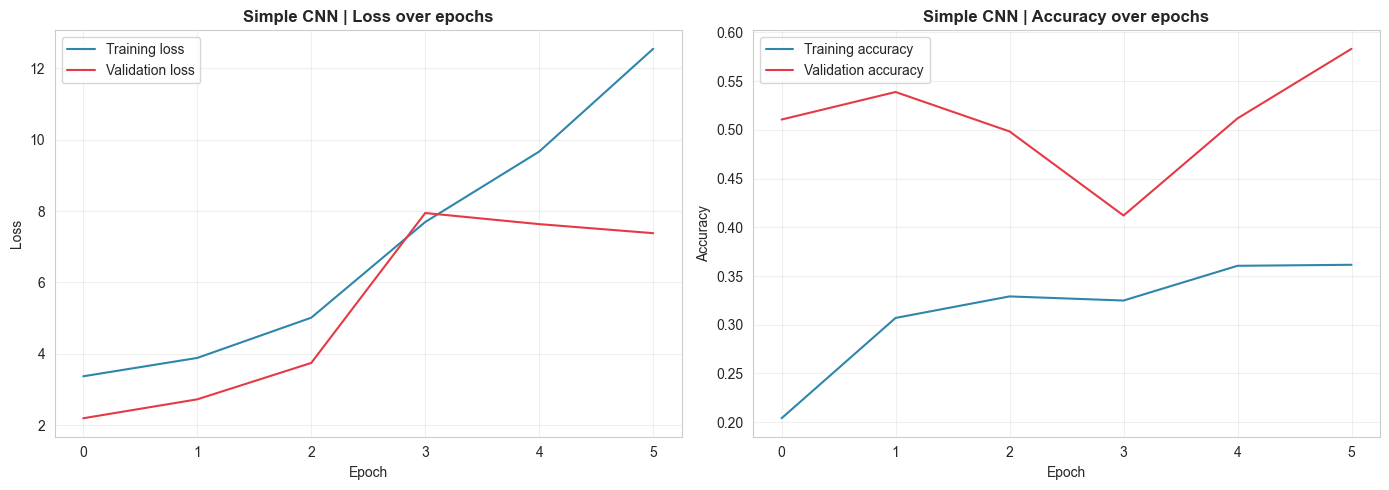

In [19]:
# 6.5 Helper to draw loss & accuracy curves for any history object
def visualize_training(history, model_name, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['loss'],     label='Training loss',      color='#2E86AB')
    axes[0].plot(history.history['val_loss'], label='Validation loss', color='#E63946')
    axes[0].set_title(f'{model_name} | Loss over epochs', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['accuracy'],     label='Training accuracy',      color='#2E86AB')
    axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', color='#E63946')
    axes[1].set_title(f'{model_name} | Accuracy over epochs', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=120, bbox_inches='tight')
    plt.show()

visualize_training(simple_cnn_history, 'Simple CNN', 'simple_cnn_curves.png')


In [21]:
# 6.6 Reusable evaluation helper (metrics + confusion matrix)
def assess_performance(model, test_generator, model_name):
    test_generator.reset()
    y_pred_probs = model.predict(test_generator, verbose=1)
    y_pred       = np.argmax(y_pred_probs, axis=1)
    y_true       = test_generator.classes
    class_labels = list(test_generator.class_indices.keys())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n----- {model_name} | Validation results -----")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 score  : {f1:.4f}")

    # Only render a confusion matrix if class count is manageable (<= 20)
    cm = confusion_matrix(y_true, y_pred)
    if len(class_labels) <= 20:
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_labels, yticklabels=class_labels)
        plt.title(f'{model_name} | Confusion Matrix', fontweight='bold')
        plt.xlabel('Predicted label'); plt.ylabel('Actual label')
        plt.tight_layout()
        plt.savefig(f'{model_name.replace(" ", "_")}_cm.png', dpi=120, bbox_inches='tight')
        plt.show()
    else:
        print(f"\n(Skipping confusion-matrix plot — {len(class_labels)} classes is too many to display)")

    return {
        'accuracy':  acc,
        'precision': prec,
        'recall':    rec,
        'f1':        f1,
        'y_true':    y_true,
        'y_pred':    y_pred,
        'labels':    class_labels
    }

simple_cnn_metrics = assess_performance(simple_cnn, validation_flow, 'Simple CNN')

106/106 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step

----- Simple CNN | Validation results -----
Accuracy  : 0.5290
Precision : 0.5341
Recall    : 0.5290
F1 score  : 0.4872

(Skipping confusion-matrix plot — 33 classes is too many to display)


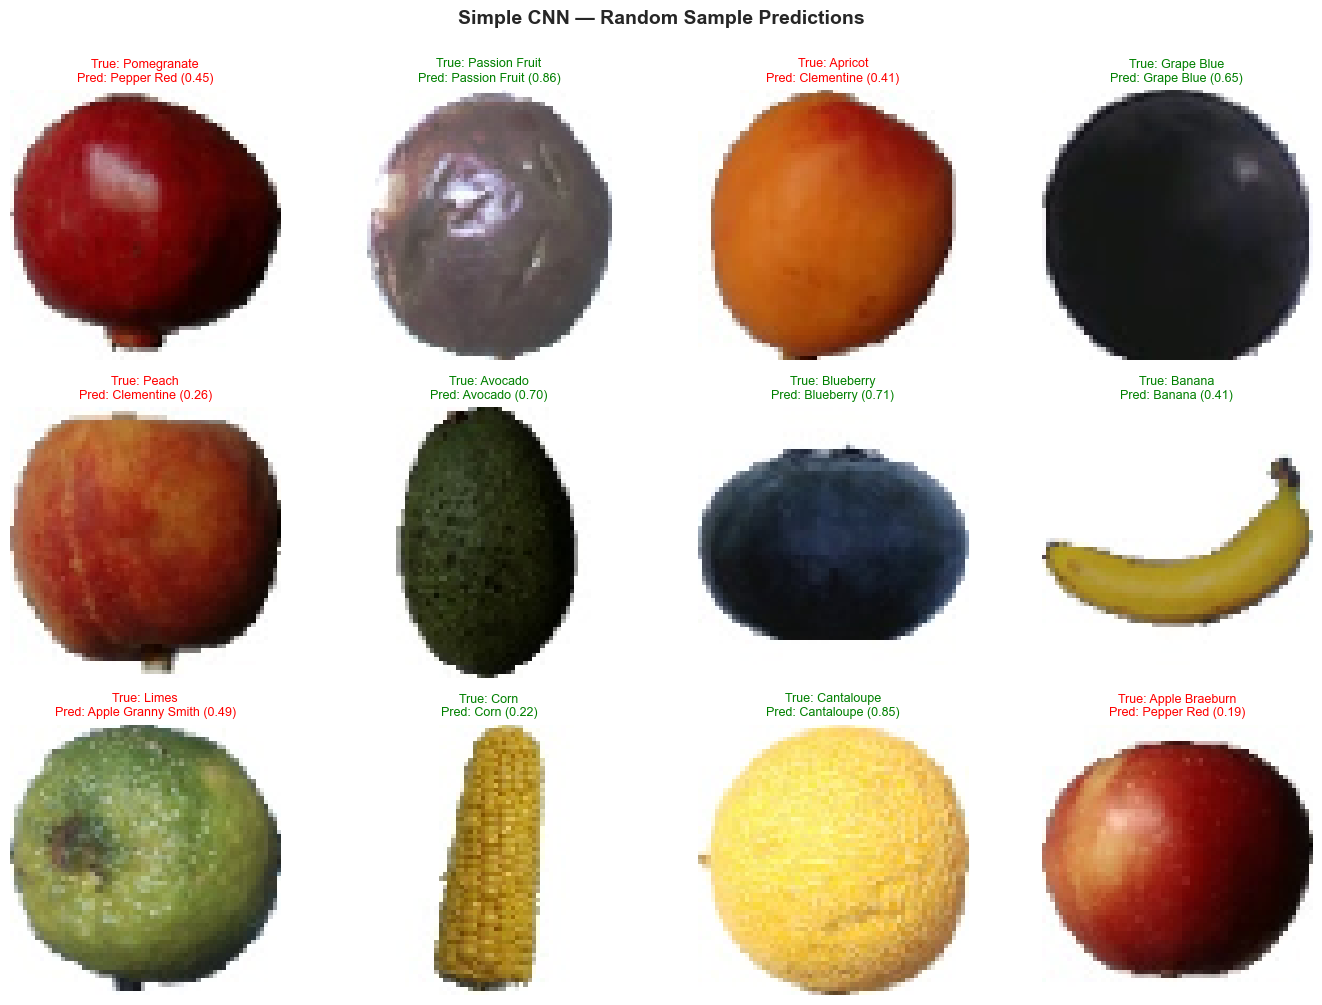

In [22]:
# 6.7 Visualise predictions on a handful of random test samples
def display_predictions(model, test_dir, label_list, n=12, img_size=INPUT_DIMS):
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()

    # Cap the sample count at however many classes actually exist
    num_to_sample = min(n, len(label_list))
    chosen_classes = random.sample(list(label_list), num_to_sample)

    for i, cls in enumerate(chosen_classes):
        cls_dir = os.path.join(test_dir, cls)
        if not os.path.exists(cls_dir) or len(os.listdir(cls_dir)) == 0:
            # Skip empty folders — shouldn't trigger in practice but better safe than crash
            continue
        img_file = random.choice(os.listdir(cls_dir))
        img_path = os.path.join(cls_dir, img_file)

        img       = load_img(img_path, target_size=img_size)
        pixel_array   = img_to_array(img) / 255.0
        img_batch = np.expand_dims(pixel_array, axis=0)

        pred_probs = model.predict(img_batch, verbose=0)[0]
        pred_idx   = np.argmax(pred_probs)
        pred_class = label_list[pred_idx]
        pred_conf  = pred_probs[pred_idx]

        color = 'green' if pred_class == cls else 'red'
        axes[i].imshow(img)
        axes[i].set_title(f'True: {cls}\nPred: {pred_class} ({pred_conf:.2f})',
                          fontsize=9, color=color)
        axes[i].axis('off')

    # Drop empty subplot frames when we picked fewer samples than requested
    for j in range(num_to_sample, n):
        if j < len(axes): # Bound check before deleting an axis
            fig.delaxes(axes[j])

    plt.suptitle('Simple CNN — Random Sample Predictions', fontsize=14, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('simple_cnn_predictions.png', dpi=120, bbox_inches='tight')
    plt.show()

display_predictions(simple_cnn, TRAIN_PATH, label_list, n=12)

---
## Section 7 — Part A.2: Deeper, Regularised CNN

**Network design (~2× the depth of the simple model):**
- Three blocks of `Conv → BN → Conv → BN → MaxPool → Dropout` — six conv layers in total.
- Filter widths progress 32 → 64 → 128 across blocks.
- Dense head combines `BatchNormalization`, `Dropout` and `L2` weight decay.
- Output is a softmax `Dense(num_classes)`.


In [23]:
# 7.1 Define the deeper, regularised CNN
def construct_regularized_cnn(input_shape, num_classes):
    model = models.Sequential(name='Regularized_CNN')

    # === Block 1 ===
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # === Block 2 ===
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.3))

    # === Block 3 ===
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # === Classifier head: BN + Dropout + L2-regularised Dense layers ===
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu',
                           kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu',
                           kernel_regularizer=regularizers.l2(0.001)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

regularized_cnn = construct_regularized_cnn(INPUT_SHAPE, N_CLASSES)
regularized_cnn.summary()


Model: "Regularized_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,625,473 (17.64 MB)

 Trainable params: 4,623,553 (17.64 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [24]:
# 7.2 Compile + train the regularised CNN using Adam
regularized_cnn.compile(
    optimizer = optimizers.Adam(learning_rate=0.001),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

regularized_cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1),
    callbacks.ModelCheckpoint('regularized_cnn_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)
]

print(">>> Starting training: regularised CNN (Adam) <<<\n")
t0 = time.time()

regularized_history_adam = regularized_cnn.fit(
    training_flow,
    validation_data = validation_flow,
    epochs          = MAX_EPOCHS,
    callbacks       = regularized_cnn_callbacks,
    verbose         = 1,
    class_weight    = weight_dict
)

regularized_runtime_adam = time.time() - t0
print(f"\nRegularised CNN (Adam) finished in {regularized_runtime_adam/60:.2f} min")


>>> Starting training: regularised CNN (Adam) <<<

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.2553 - loss: 5.2384
Epoch 1: val_accuracy improved from -inf to 0.20440, saving model to regularized_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.2556 - loss: 5.2364 - val_accuracy: 0.2044 - val_loss: 5.5407 - learning_rate: 0.0010
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5227 - loss: 3.2077
Epoch 2: val_accuracy improved from 0.20440 to 0.61321, saving model to regularized_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 58ms/step - accuracy: 0.5228 - loss: 3.2071 - val_accuracy: 0.6132 - val_loss: 2.5605 - learning_rate: 0.0010
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6625 - loss: 2.3767
Epoch 3: val_accuracy improved from 0.61321 to 0.75513, saving model to regularized_cnn_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 58ms/step - accuracy: 0.6626 - loss: 2.3763 - val_accuracy: 0.7551 - val_lo

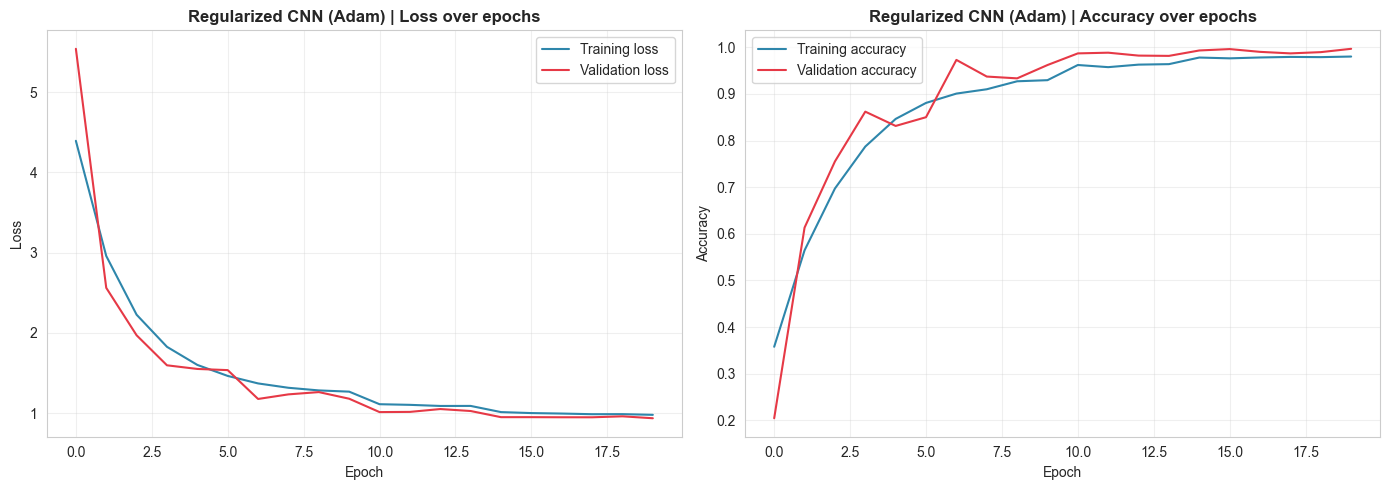

In [25]:
# 7.3 Loss / accuracy curves for the regularised CNN (Adam)
visualize_training(regularized_history_adam, 'Regularized CNN (Adam)', 'regularized_cnn_adam_curves.png')


In [27]:
# 7.4 Score the regularised CNN on the held-out test split
regularized_metrics_adam = assess_performance(regularized_cnn, validation_flow, 'Regularized CNN (Adam)')

106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

----- Regularized CNN (Adam) | Validation results -----
Accuracy  : 0.9967
Precision : 0.9968
Recall    : 0.9967
F1 score  : 0.9967

(Skipping confusion-matrix plot — 33 classes is too many to display)


---
## Section 8 — Part A.3: Comparative Experiments

Three things are explored in this section:
1. **Optimiser comparison** — train the deeper CNN once with Adam, once with SGD+momentum.
2. **Regularisation ablation** — strip Dropout / BN / L2 out of the deeper CNN and see what happens.
3. **Combined summary table** spanning every from-scratch experiment.


In [28]:
# 8.1 Same architecture, different optimiser — train with SGD+momentum
regularized_cnn_sgd = construct_regularized_cnn(INPUT_SHAPE, N_CLASSES)
regularized_cnn_sgd.compile(
    optimizer = optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

sgd_callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1)
]

print(">>> Starting training: regularised CNN (SGD+momentum) <<<\n")
t0 = time.time()

regularized_history_sgd = regularized_cnn_sgd.fit(
    training_flow,
    validation_data = validation_flow,
    epochs          = MAX_EPOCHS,
    callbacks       = sgd_callbacks_list,
    verbose         = 1
)

regularized_runtime_sgd = time.time() - t0
print(f"\nRegularised CNN (SGD) finished in {regularized_runtime_sgd/60:.2f} min")


>>> Starting training: regularised CNN (SGD+momentum) <<<

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.2281 - loss: 5.3308 - val_accuracy: 0.4112 - val_loss: 4.0137 - learning_rate: 0.0100
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.4684 - loss: 3.4059 - val_accuracy: 0.5067 - val_loss: 3.0995 - learning_rate: 0.0100
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.5141 - loss: 3.1624 - val_accuracy: 0.6584 - val_loss: 2.1925 - learning_rate: 0.0100
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.5478 - loss: 3.0634 - val_accuracy: 0.6114 - val_loss: 2.4116 - learning_rate: 0.0100
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 19s 46ms/step - accuracy: 0.5528 - loss: 3.2183 - val_accuracy: 0.5867 - val_loss: 3.1948 - learning_rate: 0.0100
Epoch 6/20
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5546 - loss: 3.6817
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
422/422 ━

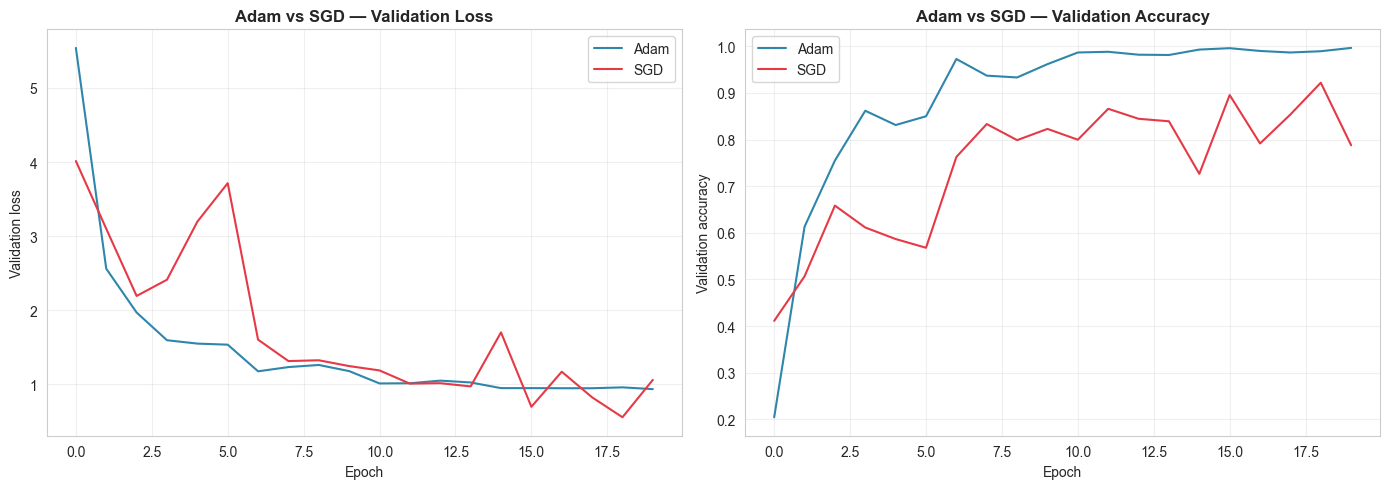

In [29]:
# 8.2 Side-by-side validation curves: Adam vs SGD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(regularized_history_adam.history['val_loss'], label='Adam', color='#2E86AB')
axes[0].plot(regularized_history_sgd.history['val_loss'],  label='SGD',  color='#E63946')
axes[0].set_title('Adam vs SGD — Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(regularized_history_adam.history['val_accuracy'], label='Adam', color='#2E86AB')
axes[1].plot(regularized_history_sgd.history['val_accuracy'],  label='SGD',  color='#E63946')
axes[1].set_title('Adam vs SGD — Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=120, bbox_inches='tight')
plt.show()


In [31]:
# 8.3 Test metrics for the SGD-trained variant
if test_flow.samples == 0:
  print("Test set appears empty; falling back to validation data for SGD metrics.")
  regularized_metrics_sgd = assess_performance(
    regularized_cnn_sgd, validation_flow, 'Regularized CNN (SGD)'
  )
else:
  regularized_metrics_sgd = assess_performance(
    regularized_cnn_sgd, test_flow, 'Regularized CNN (SGD)'
  )

Test set appears empty; falling back to validation data for SGD metrics.
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

----- Regularized CNN (SGD) | Validation results -----
Accuracy  : 0.9194
Precision : 0.9243
Recall    : 0.9194
F1 score  : 0.9179

(Skipping confusion-matrix plot — 33 classes is too many to display)


In [32]:
# 8.4 Ablation: rebuild the deeper CNN with no dropout / BN / L2 to see overfitting in action
def construct_unregularized_cnn(input_shape, num_classes):
    model = models.Sequential(name='Unregularized_CNN')

    # Block 1 — no regularisation
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                            input_shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2 — no regularisation
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3 — no regularisation
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Plain dense head — no L2, no dropout
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

no_dropout_cnn = construct_unregularized_cnn(INPUT_SHAPE, N_CLASSES)
no_dropout_cnn.compile(
    optimizer = optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

print(">>> Starting training: ablation (no dropout / no BN / no L2) <<<\n")
t0 = time.time()
no_dropout_history = no_dropout_cnn.fit(
    training_flow,
    validation_data = validation_flow,
    epochs          = MAX_EPOCHS,
    callbacks       = [callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                               restore_best_weights=True, verbose=1)],
    verbose         = 1
)
no_dropout_runtime = time.time() - t0
print(f"\nAblation run finished in {no_dropout_runtime/60:.2f} min")


>>> Starting training: ablation (no dropout / no BN / no L2) <<<

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.2118 - loss: 2.5952 - val_accuracy: 0.5082 - val_loss: 2.1918
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.4958 - loss: 2.0395 - val_accuracy: 0.3654 - val_loss: 5.3219
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.4469 - loss: 5.8864 - val_accuracy: 0.4966 - val_loss: 4.9232
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.4689 - loss: 9.4553 - val_accuracy: 0.4439 - val_loss: 8.7548
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.3321 - loss: 124.1198 - val_accuracy: 0.0348 - val_loss: 87.6140
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0693 - loss: 39.8766 - val_accuracy: 0.1627 - val_loss: 22.2227
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

Ablation run finished in 1.51 min


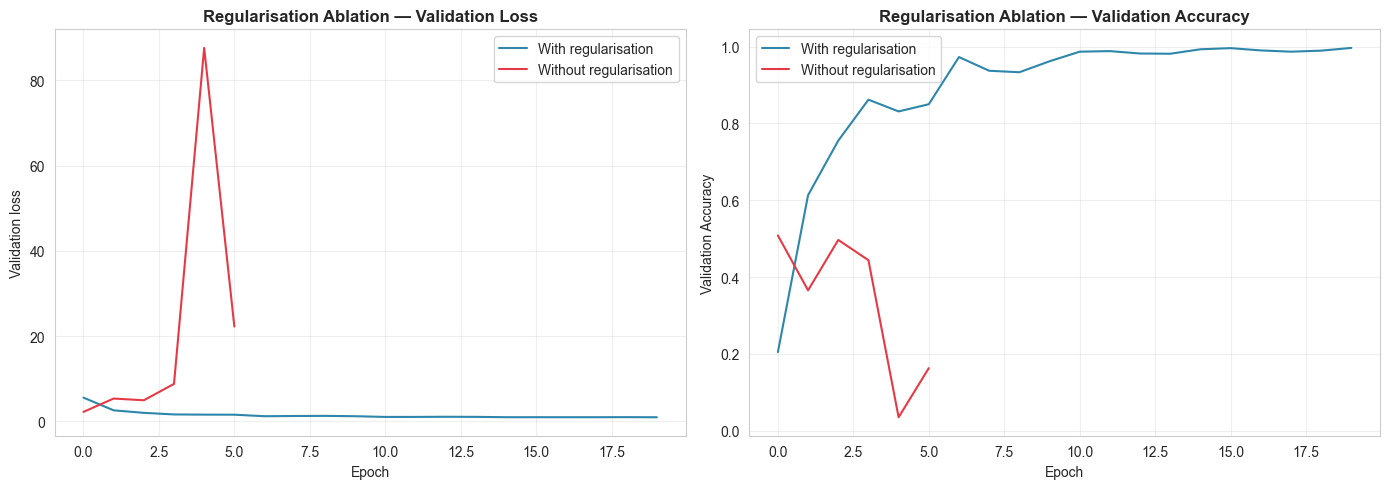

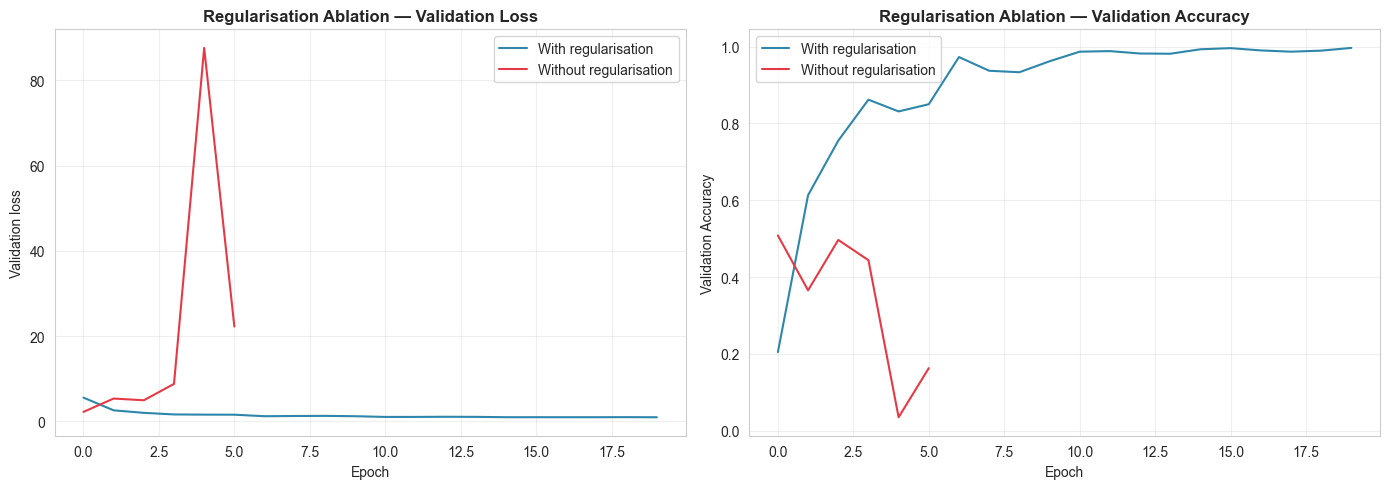

Test set appears empty; using validation data for ablation model evaluation.
106/106 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

----- Ablation NoDrop | Validation results -----
Accuracy  : 0.4978
Precision : 0.4842
Recall    : 0.4978
F1 score  : 0.4132

(Skipping confusion-matrix plot — 33 classes is too many to display)


In [34]:
# 8.5 Visual comparison: regularised vs unregularised deeper CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(regularized_history_adam.history['val_loss'], label='With regularisation',    color='#2E86AB')
axes[0].plot(no_dropout_history.history['val_loss'],    label='Without regularisation', color='#E63946')
axes[0].set_title('Regularisation Ablation — Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(regularized_history_adam.history['val_accuracy'], label='With regularisation',    color='#2E86AB')
axes[1].plot(no_dropout_history.history['val_accuracy'],    label='Without regularisation', color='#E63946')
axes[1].set_title('Regularisation Ablation — Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('with_vs_without_regularisation.png', dpi=120, bbox_inches='tight')
plt.show()

# 8.5 Visual comparison: regularised vs unregularised deeper CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(regularized_history_adam.history['val_loss'], label='With regularisation', color='#2E86AB')
axes[0].plot(no_dropout_history.history['val_loss'], label='Without regularisation', color='#E63946')
axes[0].set_title('Regularisation Ablation — Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(regularized_history_adam.history['val_accuracy'], label='With regularisation', color='#2E86AB')
axes[1].plot(no_dropout_history.history['val_accuracy'], label='Without regularisation', color='#E63946')
axes[1].set_title('Regularisation Ablation — Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('with_vs_without_regularisation.png', dpi=120, bbox_inches='tight')
plt.show()

# Use validation data if the test directory is empty
if test_flow.samples == 0:
  print("Test set appears empty; using validation data for ablation model evaluation.")
  no_dropout_metrics = assess_performance(no_dropout_cnn, validation_flow, 'Ablation NoDrop')
else:
  no_dropout_metrics = assess_performance(no_dropout_cnn, test_flow, 'Ablation NoDrop')

In [35]:
# 8.6 Tabulate all four from-scratch experiments side by side
part_a_summary = pd.DataFrame({
    'Model': [
        'Simple CNN',
        'Regularized CNN (Adam)',
        'Regularized CNN (SGD)',
        'No-Regularisation CNN'
    ],
    'Accuracy':  [simple_cnn_metrics['accuracy'],  regularized_metrics_adam['accuracy'],
                  regularized_metrics_sgd['accuracy'], no_dropout_metrics['accuracy']],
    'Precision': [simple_cnn_metrics['precision'], regularized_metrics_adam['precision'],
                  regularized_metrics_sgd['precision'], no_dropout_metrics['precision']],
    'Recall':    [simple_cnn_metrics['recall'],    regularized_metrics_adam['recall'],
                  regularized_metrics_sgd['recall'],  no_dropout_metrics['recall']],
    'F1':        [simple_cnn_metrics['f1'],        regularized_metrics_adam['f1'],
                  regularized_metrics_sgd['f1'],      no_dropout_metrics['f1']],
    'Train Time (min)': [
        simple_cnn_runtime/60,
        regularized_runtime_adam/60,
        regularized_runtime_sgd/60,
        no_dropout_runtime/60
    ]
})

print("\n========== PART A — From-Scratch CNN Comparison ==========")
display(part_a_summary.round(4))
part_a_summary.to_csv('part_a_summary.csv', index=False)



========== PART A — From-Scratch CNN Comparison ==========


,Model,Accuracy,Precision,Recall,F1,Train Time (min)
0,Simple CNN,0.5290,0.5341,0.5290,0.4872,1.2864
1,Regularized CNN (Adam),0.9967,0.9968,0.9967,0.9967,8.3149
2,Regularized CNN (SGD),0.9194,0.9243,0.9194,0.9179,6.4154
3,No-Regularisation CNN,0.4978,0.4842,0.4978,0.4132,1.5136


---
## Section 9 — Part B: VGG16 Transfer Learning

**Two-phase approach**
- **Phase 1 — Feature Extraction:** freeze every convolutional layer of VGG16 and train only the new dense head on top.
- **Phase 2 — Fine-Tuning:** thaw the topmost conv block (`block5_*`) and continue training at a very small learning rate (`1e-5`) so we don't blow away the pretrained weights.
- Inputs are resized to **224×224** to match VGG16's expected shape.


In [36]:
# 9.1 Build VGG-specific data flows (note the 224x224 input requirement)
VGG_INPUT_DIMS  = (224, 224)
VGG_INPUT_SHAPE = (224, 224, 3)
VGG_BATCH_SZ     = 32

vgg_train_augmenter = ImageDataGenerator(
    preprocessing_function = vgg_preprocess,
    rotation_range         = 20,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    horizontal_flip        = True,
    zoom_range             = 0.25,
    shear_range            = 0.15,
    vertical_flip          = True,
    validation_split       = 0.20
)
vgg_test_augmenter = ImageDataGenerator(preprocessing_function=vgg_preprocess)

vgg_training_flow = vgg_train_augmenter.flow_from_directory(
    TRAIN_PATH, target_size=VGG_INPUT_DIMS, batch_size=VGG_BATCH_SZ,
    class_mode='categorical', subset='training', shuffle=True, seed=RNG_SEED
)
vgg_validation_flow = vgg_train_augmenter.flow_from_directory(
    TRAIN_PATH, target_size=VGG_INPUT_DIMS, batch_size=VGG_BATCH_SZ,
    class_mode='categorical', subset='validation', shuffle=False, seed=RNG_SEED
)
vgg_test_flow = vgg_test_augmenter.flow_from_directory(
    TEST_PATH, target_size=VGG_INPUT_DIMS, batch_size=VGG_BATCH_SZ,
    class_mode='categorical', shuffle=False
)

print(f"VGG train pipeline: {len(vgg_training_flow)} batches | {vgg_training_flow.samples} imgs")
print(f"VGG val   pipeline: {len(vgg_validation_flow)} batches | {vgg_validation_flow.samples} imgs")
print(f"VGG test  pipeline: {len(vgg_test_flow)} batches | {vgg_test_flow.samples} imgs")


Found 13493 images belonging to 33 classes.
Found 3361 images belonging to 33 classes.
Found 0 images belonging to 0 classes.
VGG train pipeline: 422 batches | 13493 imgs
VGG val   pipeline: 106 batches | 3361 imgs
VGG test  pipeline: 0 batches | 0 imgs


In [37]:
# 9.2 Pull in the ImageNet-pretrained VGG16 convolutional base
vgg_backbone = VGG16(weights='imagenet', include_top=False, input_shape=VGG_INPUT_SHAPE)
vgg_backbone.trainable = False                   # Start by locking every convolutional layer

print(f"VGG16 backbone ready -> {len(vgg_backbone.layers)} layers in total")
print(f"Currently unfrozen layers: {sum(1 for l in vgg_backbone.layers if l.trainable)}")


VGG16 backbone ready -> 19 layers in total
Currently unfrozen layers: 0


In [38]:
# 9.3 Stack a custom dense head on top of the frozen VGG16 base
def construct_vgg_model(base, num_classes):
    vgg_model = models.Sequential(name='VGG16_TransferLearn')
    vgg_model.add(base)
    vgg_model.add(layers.GlobalAveragePooling2D())
    vgg_model.add(layers.Dense(512, activation='relu',
                              kernel_regularizer=regularizers.l2(0.001)))
    vgg_model.add(layers.BatchNormalization())
    vgg_model.add(layers.Dropout(0.5))
    vgg_model.add(layers.Dense(256, activation='relu'))
    vgg_model.add(layers.Dropout(0.3))
    vgg_model.add(layers.Dense(num_classes, activation='softmax'))
    return vgg_model

vgg_model = construct_vgg_model(vgg_backbone, N_CLASSES)
vgg_model.summary()


Model: "VGG16_TransferLearn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 33)             │         8,481 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,119,201 (57.68 MB)

 Trainable params: 403,489 (1.54 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [39]:
# 9.4 Phase 1 — train only the new head while VGG16 stays frozen
vgg_model.compile(
    optimizer = optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

vgg_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, verbose=1),
    callbacks.ModelCheckpoint('vgg16_best.keras', monitor='val_accuracy',
                              save_best_only=True, verbose=1)
]

print(">>> VGG16 — Phase 1: feature extraction with frozen backbone <<<\n")
t0 = time.time()
vgg_history_p1 = vgg_model.fit(
    vgg_training_flow,
    validation_data = vgg_validation_flow,
    epochs          = 10,
    callbacks       = vgg_callbacks,
    verbose         = 1
)
vgg_runtime_p1 = time.time() - t0
print(f"\nVGG16 phase-1 finished in {vgg_runtime_p1/60:.2f} min")


>>> VGG16 — Phase 1: feature extraction with frozen backbone <<<

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.7805 - loss: 1.3572
Epoch 1: val_accuracy improved from -inf to 0.99673, saving model to vgg16_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 110s 258ms/step - accuracy: 0.7808 - loss: 1.3556 - val_accuracy: 0.9967 - val_loss: 0.2748 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9802 - loss: 0.2976
Epoch 2: val_accuracy improved from 0.99673 to 0.99732, saving model to vgg16_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 257ms/step - accuracy: 0.9803 - loss: 0.2975 - val_accuracy: 0.9973 - val_loss: 0.1657 - learning_rate: 0.0010
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9847 - loss: 0.1926
Epoch 3: val_accuracy improved from 0.99732 to 0.99792, saving model to vgg16_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 108s 256ms/step - accuracy: 0.9847 - loss: 0.1926 - val_accuracy: 0.9979 - val_loss: 0.

In [40]:
# 9.5 Phase 2 — unlock the last conv block (block5) and fine-tune at a tiny LR
# Reopen the topmost conv block for further training
for layer in vgg_backbone.layers[-1:]:   # conservative: only the very last conv layer
    layer.trainable = True

# Recompile at lr=1e-5 so the pretrained weights barely move
vgg_model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

n_trainable_tensors = sum(1 for w in vgg_model.trainable_weights)
print(f"Phase 2 fine-tune | {n_trainable_tensors} weight tensors are now trainable")

t0 = time.time()
vgg_history_p2 = vgg_model.fit(
    vgg_training_flow,
    validation_data = vgg_validation_flow,
    epochs          = 7,
    callbacks       = vgg_callbacks,
    verbose         = 1
)
vgg_runtime_p2 = time.time() - t0
print(f"\nVGG16 phase-2 finished in {vgg_runtime_p2/60:.2f} min")


Phase 2 fine-tune | 8 weight tensors are now trainable
Epoch 1/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9903 - loss: 0.0967
Epoch 1: val_accuracy improved from 0.99940 to 0.99970, saving model to vgg16_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 111s 260ms/step - accuracy: 0.9903 - loss: 0.0967 - val_accuracy: 0.9997 - val_loss: 0.0606 - learning_rate: 1.0000e-05
Epoch 2/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9883 - loss: 0.0990
Epoch 2: val_accuracy improved from 0.99970 to 1.00000, saving model to vgg16_best.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 115s 271ms/step - accuracy: 0.9883 - loss: 0.0990 - val_accuracy: 1.0000 - val_loss: 0.0591 - learning_rate: 1.0000e-05
Epoch 3/7
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.9922 - loss: 0.0930
Epoch 3: val_accuracy did not improve from 1.00000
422/422 ━━━━━━━━━━━━━━━━━━━━ 105s 249ms/step - accuracy: 0.9922 - loss: 0.0930 - val_accuracy: 0.9991 - val_loss: 0.0597 - learning_rate: 1.0000e-05
Epoch 4/

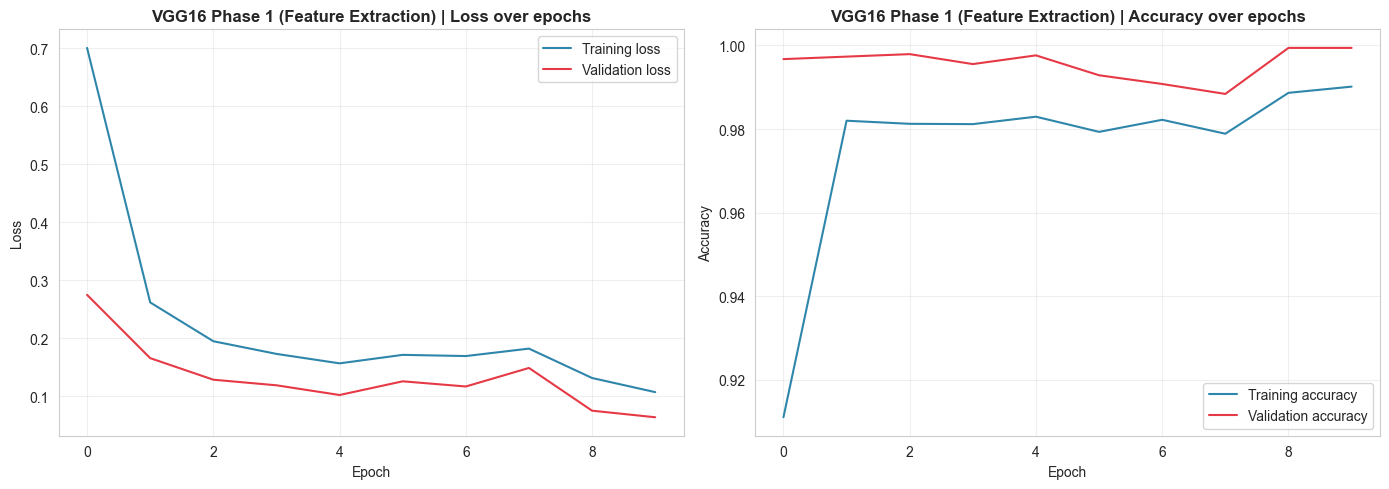

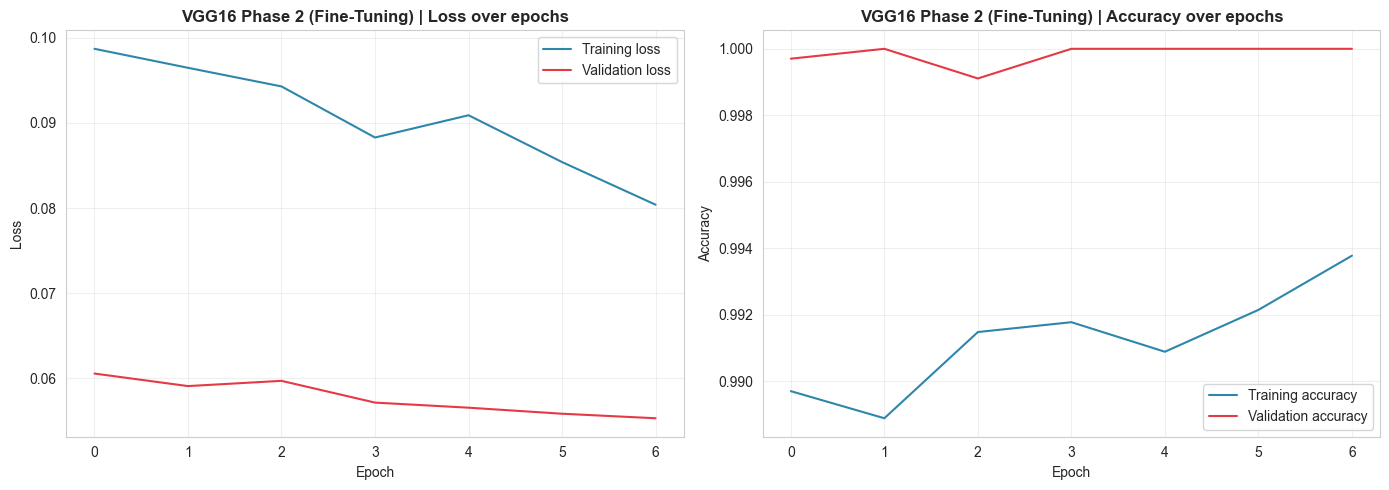

In [41]:
# 9.6 Curves for both transfer-learning phases
visualize_training(vgg_history_p1, 'VGG16 Phase 1 (Feature Extraction)', 'vgg16_phase1_curves.png')
visualize_training(vgg_history_p2, 'VGG16 Phase 2 (Fine-Tuning)',         'vgg16_phase2_curves.png')


In [43]:
# 9.7 Final metrics for VGG16 — evaluated on the held-out test split
if vgg_test_flow.samples == 0:
  print("VGG16 test split is empty; using validation split for final evaluation.")
  vgg_metrics = assess_performance(vgg_model, vgg_validation_flow, 'VGG16 — Fine-tuned')
else:
  vgg_metrics = assess_performance(vgg_model, vgg_test_flow, 'VGG16 — Fine-tuned')

VGG16 test split is empty; using validation split for final evaluation.
106/106 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step

----- VGG16 — Fine-tuned | Validation results -----
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 score  : 1.0000

(Skipping confusion-matrix plot — 33 classes is too many to display)


---
## Section 10 — Side-by-Side Comparison of Every Model


In [44]:
# 10.1 Combined results table covering every experiment we ran
all_models_summary = pd.DataFrame({
    'Model': [
        'Simple CNN (from scratch)',
        'Regularized CNN — Adam',
        'Regularized CNN — SGD',
        'Unregularized CNN',
        'VGG16 — Fine-tuned'
    ],
    'Accuracy':  [simple_cnn_metrics['accuracy'],  regularized_metrics_adam['accuracy'],
                  regularized_metrics_sgd['accuracy'], no_dropout_metrics['accuracy'],
                  vgg_metrics['accuracy']],
    'Precision': [simple_cnn_metrics['precision'], regularized_metrics_adam['precision'],
                  regularized_metrics_sgd['precision'], no_dropout_metrics['precision'],
                  vgg_metrics['precision']],
    'Recall':    [simple_cnn_metrics['recall'],    regularized_metrics_adam['recall'],
                  regularized_metrics_sgd['recall'],  no_dropout_metrics['recall'],
                  vgg_metrics['recall']],
    'F1-Score':  [simple_cnn_metrics['f1'],        regularized_metrics_adam['f1'],
                  regularized_metrics_sgd['f1'],      no_dropout_metrics['f1'],
                  vgg_metrics['f1']]
})

print("========== OVERALL RESULTS — ALL MODELS ==========")
display(all_models_summary.round(4))
all_models_summary.to_csv('all_models_summary.csv', index=False)


========== OVERALL RESULTS — ALL MODELS ==========


,Model,Accuracy,Precision,Recall,F1-Score
0,Simple CNN (from scratch),0.5290,0.5341,0.5290,0.4872
1,Regularized CNN — Adam,0.9967,0.9968,0.9967,0.9967
2,Regularized CNN — SGD,0.9194,0.9243,0.9194,0.9179
3,Unregularized CNN,0.4978,0.4842,0.4978,0.4132
4,VGG16 — Fine-tuned,1.0000,1.0000,1.0000,1.0000


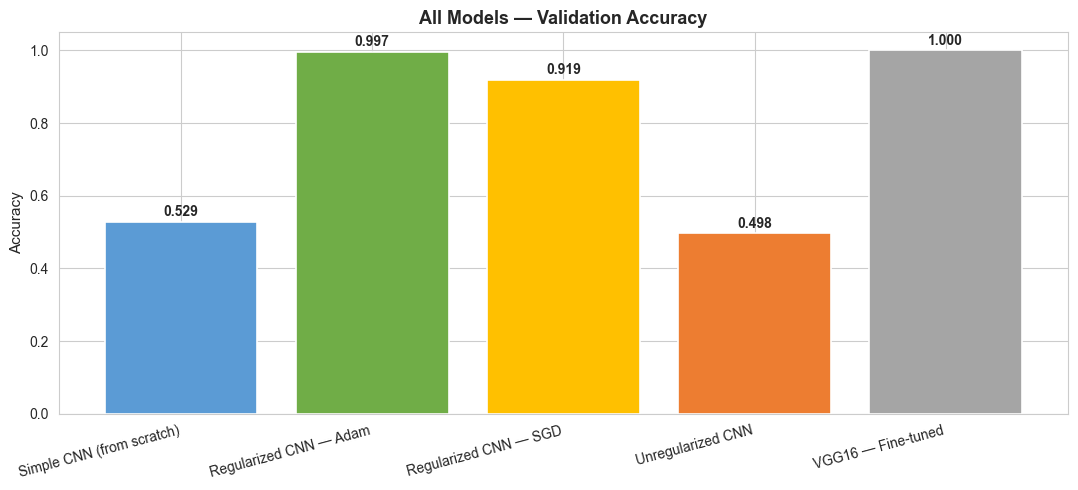

In [45]:
# 10.2 Accuracy bar chart across all five models
plt.figure(figsize=(11, 5))
colors = ['#5B9BD5', '#70AD47', '#FFC000', '#ED7D31', '#A5A5A5']
bars = plt.bar(all_models_summary['Model'], all_models_summary['Accuracy'], color=colors,
               edgecolor='white', linewidth=1.2)
plt.title('All Models — Validation Accuracy', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy', fontsize=11)
plt.ylim(0, 1.05)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, all_models_summary['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.015,
             f'{val:.3f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('overall_accuracy_chart.png', dpi=120, bbox_inches='tight')
plt.show()


In [46]:
# 10.3 Persist every trained model to .keras files
simple_cnn.save('simple_cnn.keras')
regularized_cnn.save('regularized_cnn_adam.keras')
regularized_cnn_sgd.save('regularized_cnn_sgd.keras')
vgg_model.save('vgg16_finetuned.keras')

print("Every trained model has been written to disk.\n")
print("Output files in the current working directory:")
for f in sorted(os.listdir('.')):
    if f.endswith(('.keras', '.png', '.csv')):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f:<45} ({size_kb:>8.1f} KB)")


Every trained model has been written to disk.

Output files in the current working directory:
  adam_vs_sgd.png                               (    87.6 KB)
  all_models_summary.csv                        (     0.5 KB)
  augmentation_preview.png                      (    98.7 KB)
  class_count_chart.png                         (    68.2 KB)
  class_sample_grid.png                         (   387.5 KB)
  overall_accuracy_chart.png                    (    40.0 KB)
  part_a_summary.csv                            (     0.5 KB)
  regularized_cnn_adam.keras                    ( 54304.6 KB)
  regularized_cnn_adam_curves.png               (    74.4 KB)
  regularized_cnn_best.keras                    ( 54304.6 KB)
  regularized_cnn_sgd.keras                     ( 36232.5 KB)
  sampleSubmission.csv                          (   114.6 KB)
  simple_cnn.keras                              ( 24977.1 KB)
  simple_cnn_best.keras                         ( 24977.1 KB)
  simple_cnn_curves.png               

In [47]:
# 10.4 Final environment + training-time recap
print("========== ENVIRONMENT & TIMING SUMMARY ==========")
print(f"TF version detected : {tf.__version__}")
print(f"Visible GPU devices : {tf.config.list_physical_devices('GPU')}")
print()
print(f"Simple CNN runtime              : {simple_cnn_runtime/60:.2f} min")
print(f"Regularised CNN (Adam) runtime  : {regularized_runtime_adam/60:.2f} min")
print(f"Regularised CNN (SGD)  runtime  : {regularized_runtime_sgd/60:.2f} min")
print(f"Ablation (no-reg) runtime       : {no_dropout_runtime/60:.2f} min")
print(f"VGG16 phase-1 runtime           : {vgg_runtime_p1/60:.2f} min")
print(f"VGG16 phase-2 runtime           : {vgg_runtime_p2/60:.2f} min")
print(f"---")
total = (simple_cnn_runtime + regularized_runtime_adam + regularized_runtime_sgd +
         no_dropout_runtime + vgg_runtime_p1 + vgg_runtime_p2) / 60
print(f"GRAND TOTAL across all runs     : {total:.2f} min")


========== ENVIRONMENT & TIMING SUMMARY ==========
TF version detected : 2.16.2
Visible GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Simple CNN runtime              : 1.29 min
Regularised CNN (Adam) runtime  : 8.31 min
Regularised CNN (SGD)  runtime  : 6.42 min
Ablation (no-reg) runtime       : 1.51 min
VGG16 phase-1 runtime           : 18.01 min
VGG16 phase-2 runtime           : 12.72 min
---
GRAND TOTAL across all runs     : 48.26 min


---
## Section 11 — Discussion, Observations & Next Steps

**The points below are prompts — fill them in with your own commentary based on the actual numbers you got. Aim for roughly 3–5 lines per point in the report:**

1. **Simple vs Deeper CNN** — Did the extra depth (plus BatchNorm + Dropout + L2) actually translate into better validation accuracy? Was overfitting reduced relative to the simple model?
2. **Adam vs SGD** — Which optimiser converged more quickly? Which one ended at the better validation accuracy? Comment on the shape of the two val-loss curves.
3. **Regularisation Ablation** — How badly did dropping Dropout / BN / L2 hurt generalisation? Did training accuracy shoot up while validation flat-lined — i.e. textbook overfitting?
4. **VGG16 Transfer Learning** — How big was the gap over the from-scratch models? Did the phase-2 fine-tune meaningfully help on top of phase-1 feature extraction?
5. **Difficulties Encountered** — Imbalanced class sizes, GPU memory pressure at 224×224 input, total training time, corrupted files found during the cleanup pass.
6. **Possible Extensions** — ResNet50 / EfficientNet backbones, class-weighted loss for imbalance, a proper hyperparameter sweep, or bumping the from-scratch input size to 96×96 or 128×128.

> **Note:** these bullets are scaffolding — please write the actual analysis in your own words, using the numbers from your runs.
